In [2]:
from dinosaw import PEModel
from dinosaw.utils import load_image, normalize, resize_crop, do_2D_pca, convert_image, probe, closest_crop
from dinosaw.models.vit_wrapper import (
    PretrainedViTWrapper,
    MODEL_LIST,
)
from dinosaw.datasets.translate_featurise import translate_featurise
import matplotlib.pyplot as plt
import cv2
import torch

/home/ab_aimd_anja_20884/anaconda3/envs/flash_attn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


flash attention installed


In [24]:
vit_wrapper = PretrainedViTWrapper(MODEL_LIST[1], add_flash_attn=True, device="cuda").half()
#model_overfitted = PEModel.load_from_checkpoint("/home/ab_aimd_anja_20884/Pawlowsky_Moritz/England/DINOMO/dinosaw/trained_models/test_long_train-epoch=468-val_loss=0.17.ckpt").half()
# Overfitted??
model_old = PEModel.load_from_checkpoint("trained_models/test-epoch=67-val_loss=0.18.ckpt", strict=False).half()
model = PEModel.load_from_checkpoint("trained_models/normalised_alibi-epoch=09-val_loss=0.26.ckpt", strict=False).half()
#model_test = PEModel.load_from_checkpoint("/home/ab_aimd_anja_20884/Pawlowsky_Moritz/England/DINOMO/dinosaw/trained_models_in_steps/nothing-epoch=39-val_loss=0.01.ckpt", strict=False).half()
model_test = PEModel.load_from_checkpoint("/home/ab_aimd_anja_20884/Pawlowsky_Moritz/England/DINOMO/dinosaw/trained_models_in_steps/added_alibi_gradual_fade_abs_pos_embed_long-epoch=470-val_loss=0.17_last_epoch.ckpt", strict=False, use_alibi=True, remove_pos_embed=False)


/home/ab_aimd_anja_20884/anaconda3/envs/flash_attn/lib/python3.12/site-packages/lightning/pytorch/core/saving.py:195: Found keys that are not in the model state dict but in the checkpoint: ['vit.model.blocks.0.attn.m', 'vit.model.blocks.1.attn.m', 'vit.model.blocks.2.attn.m', 'vit.model.blocks.3.attn.m', 'vit.model.blocks.4.attn.m', 'vit.model.blocks.5.attn.m', 'vit.model.blocks.6.attn.m', 'vit.model.blocks.7.attn.m', 'vit.model.blocks.8.attn.m', 'vit.model.blocks.9.attn.m', 'vit.model.blocks.10.attn.m', 'vit.model.blocks.11.attn.m']


In [6]:
# import types

# from dinosaw.models.overwriting_methods import _pos_embed_no_pos
# model_test.vit._pos_embed = types.MethodType(_pos_embed_no_pos, model_test.vit)
# model_test.vit.model.pos_embed = torch.nn.Parameter(torch.zeros_like(model_test.vit.model.pos_embed), requires_grad=False) #setting pos_encoding to zero without gradient

model_old.vit.model.pos_embed

Parameter containing:
tensor([[[-0.0113,  0.0086, -0.0091,  ...,  0.0057, -0.0008, -0.0127],
         [-0.0095,  0.0066, -0.0085,  ...,  0.0049, -0.0029, -0.0081],
         [-0.0058,  0.0050, -0.0054,  ...,  0.0016, -0.0035, -0.0045],
         ...,
         [ 0.0040, -0.0022,  0.0003,  ...,  0.0020,  0.0041, -0.0015],
         [ 0.0052, -0.0031, -0.0002,  ...,  0.0010,  0.0056,  0.0042],
         [ 0.0059, -0.0035, -0.0019,  ...,  0.0002,  0.0069,  0.0085]]],
       device='cuda:0', dtype=torch.float16, requires_grad=True)

In [7]:
#model_test.vit.model.pos_drop = torch.nn.Dropout(p=1)

In [8]:
img_size=1*518
#test_img = load_image("images/default_image.jpg", resize_crop((img_size, img_size), (img_size, img_size)))[0]
test_img = load_image("images/diff_shapes_518.png", resize_crop((img_size, img_size), (img_size, img_size)))[0]

In [9]:
res_dino, res_overfitted, res_our, res_our_test = (
    vit_wrapper.forward_features(test_img, make_2D=True),
    model_old(test_img),
    model(test_img),
    model_test(test_img.float())
)

In [10]:
cleaned = translate_featurise(test_img, vit_wrapper)

In [11]:
res_our.shape
res_our.flatten(1).shape

torch.Size([1, 525696])

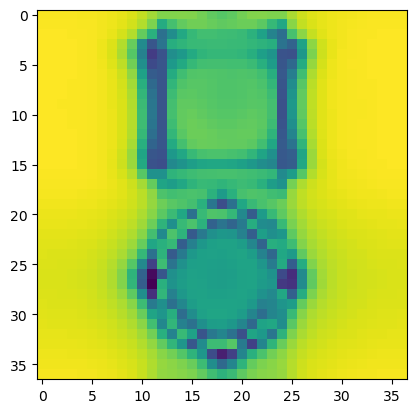

In [12]:
plt.imshow(torch.nn.functional.cosine_similarity(res_our_test.cpu(), cleaned).detach().numpy().squeeze())

(array([2.0000e+01, 3.2000e+01, 7.7000e+01, 5.3000e+01, 5.3000e+01,
        4.2000e+01, 4.9000e+01, 4.5000e+01, 3.2000e+01, 4.0000e+01,
        5.7000e+01, 1.1200e+02, 1.2600e+02, 1.3500e+02, 8.2000e+01,
        7.1000e+01, 9.5000e+01, 6.9000e+01, 3.6000e+01, 2.0000e+01,
        3.3000e+01, 2.1000e+01, 3.0000e+01, 2.2000e+01, 1.9000e+01,
        2.1000e+01, 2.0000e+01, 2.7000e+01, 2.1000e+01, 1.7000e+01,
        1.3000e+01, 1.9000e+01, 1.7000e+01, 1.2000e+01, 1.4000e+01,
        2.0000e+01, 2.1000e+01, 1.0000e+01, 1.5000e+01, 1.2000e+01,
        1.5000e+01, 1.1000e+01, 1.2000e+01, 1.6000e+01, 3.2000e+01,
        6.7000e+01, 2.2000e+02, 2.3200e+02, 1.4900e+02, 1.3200e+02,
        9.6000e+01, 7.9000e+01, 9.2000e+01, 6.7000e+01, 9.4000e+01,
        1.1500e+02, 1.6600e+02, 1.1200e+02, 1.2800e+02, 1.7600e+02,
        2.4300e+02, 2.8900e+02, 3.6200e+02, 3.6400e+02, 3.9700e+02,
        4.7300e+02, 5.5300e+02, 5.8000e+02, 7.0500e+02, 8.5400e+02,
        7.5300e+02, 8.7900e+02, 1.0130e+03, 1.27

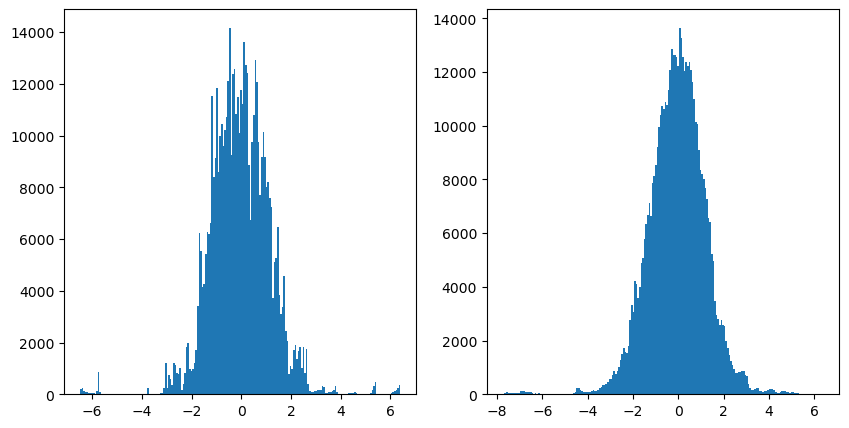

In [13]:
fig, ax = plt.subplots(1,2, figsize=(10,5))
ax[0].hist(res_our_test.detach().cpu().numpy().flatten(), bins=200)
ax[1].hist(cleaned.detach().cpu().numpy().flatten(), bins=200)

Text(0.5, 1.0, 'DINO cleaned through translation')

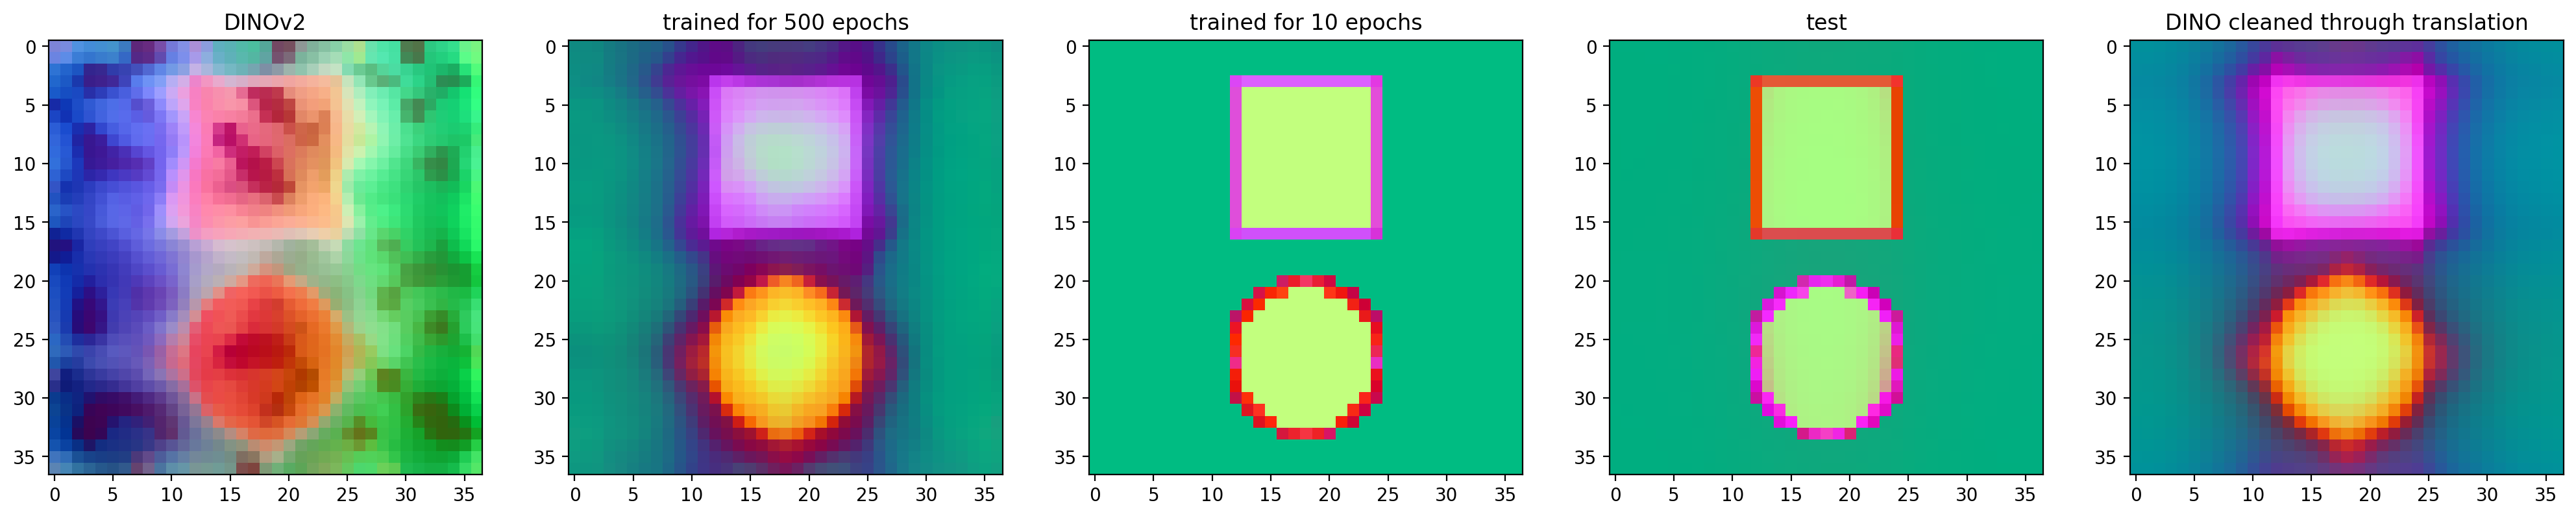

In [14]:
fig, ax = plt.subplots(1,5, figsize=(25, 5),dpi=200)
ax[0].imshow(do_2D_pca(res_dino.squeeze(), post_norm="minmax"))
ax[0].set_title("DINOv2")
ax[1].imshow(do_2D_pca(res_overfitted.squeeze(), post_norm="minmax"))
ax[1].set_title("trained for 500 epochs")
ax[2].imshow(do_2D_pca(res_our.squeeze(), post_norm="minmax"))
ax[2].set_title("trained for 10 epochs")
ax[3].imshow(do_2D_pca(res_our_test.squeeze(), post_norm="minmax"))
ax[3].set_title("test")
ax[4].imshow(do_2D_pca(cleaned.squeeze(), post_norm="minmax"))
ax[4].set_title("DINO cleaned through translation")

(384, 37, 37)
(384, 37, 37)


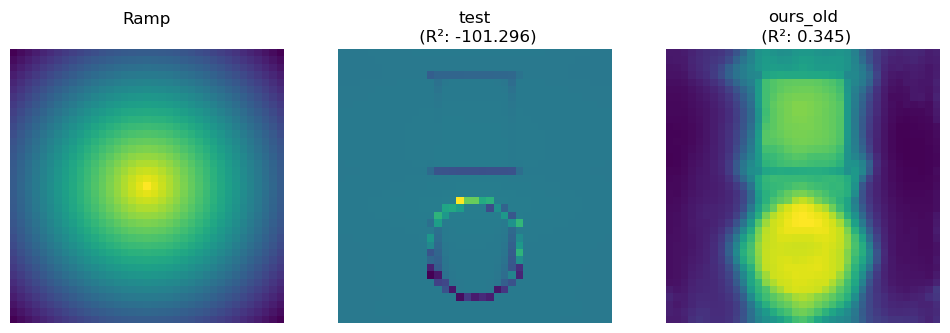

In [ ]:
from dinosaw.utils import probe
probe([res_our_test, res_our], [False]*2, ["test", "ours_old"], ramp="radial", by_channel=False)

In [ ]:
zero_tensor = torch.zeros_like(test_img)
test_out_black = model_test(zero_tensor.float())
our_black = model(zero_tensor.half())
dino_black = vit_wrapper.forward_features(zero_tensor.half(), make_2D=True)

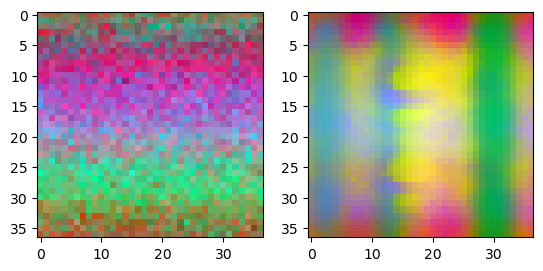

In [ ]:
fig, ax = plt.subplots(1,2)
ax[0].imshow(do_2D_pca(test_out_black.squeeze(), post_norm="minmax"))
ax[1].imshow(do_2D_pca(dino_black.squeeze(), post_norm="minmax"))

(384, 37, 37)
(384, 37, 37)


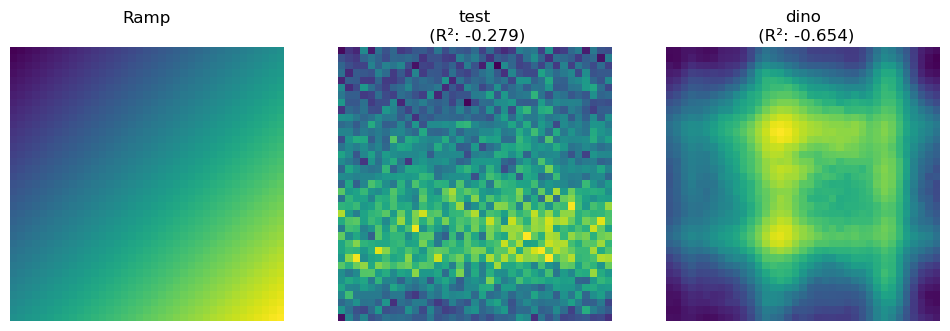

In [ ]:
probe([test_out_black, dino_black], [False]*2, ["test", "dino"], ramp="diag", by_channel=False, mask_step=4)

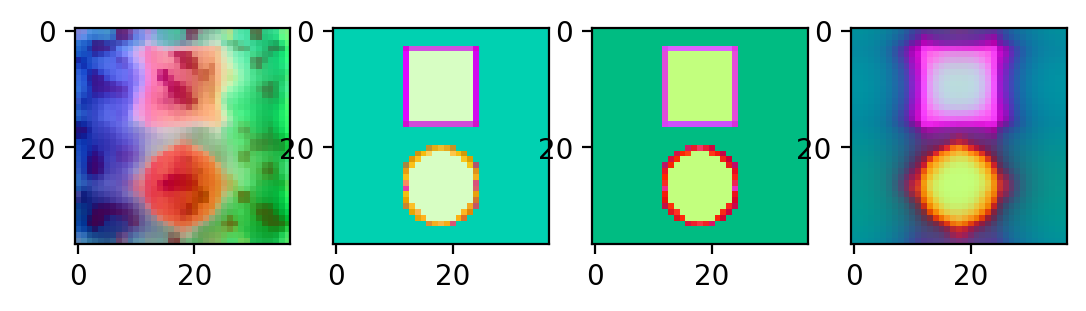

In [18]:
fig, ax = plt.subplots(1,4, dpi=200)
ax[0].imshow(do_2D_pca(res_dino.squeeze(), post_norm="minmax"))
ax[1].imshow(do_2D_pca(res_overfitted.squeeze(), post_norm="minmax"))
ax[2].imshow(do_2D_pca(res_our.squeeze(), post_norm="minmax"))
ax[3].imshow(do_2D_pca(cleaned.squeeze(), post_norm="minmax"))